# 01 · Exploratory Data Analysis

Explore the MovieLens dataset: rating distributions, user/item sparsity, genre breakdown, and temporal patterns.

In [1]:
import sys

sys.path.insert(0, '..')


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from config import REPORTS_DIR

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1 · Load Raw Data

In [2]:
from src.data.load_data import get_data

train_raw, val_raw = get_data()
df = pd.concat([train_raw, val_raw], ignore_index=True)

print(f'Total records : {len(df):,}')
print(f'Unique users  : {df.user_id.nunique():,}')
print(f'Unique movies : {df.movie_id.nunique():,}')
print(f'Rating range  : {df.rating.min()} – {df.rating.max()}')
df.head()

Loading from local cache...
Total records : 990,425
Unique users  : 44,088
Unique movies : 15,603
Rating range  : 0.5 – 5.0


,imdbId,tmdbId,movie_id,user_id,rating,title,genres,posters
0,tt2096673,150540,2307,11923,3.5,Inside Out (2015),Adventure|Animation|Children|Comedy|Drama|Fantasy,https://m.media-amazon.com/images/M/MV5BOTgxMD...
1,tt5160928,393732,7157,32503,3.0,Mean Dreams (2017),Thriller,https://m.media-amazon.com/images/M/MV5BMDM2OD...
2,tt3498820,271110,1398,20241,3.0,Captain America: Civil War (2016),Action|Sci-Fi|Thriller,https://m.media-amazon.com/images/M/MV5BMjQ0MT...
3,tt3040964,278927,2625,42975,5.0,The Jungle Book (2016),Adventure|Drama|Fantasy,https://m.media-amazon.com/images/M/MV5BMTc3NT...
4,tt5308322,440021,8457,31336,3.0,Happy Death Day (2017),Horror|Mystery|Thriller,https://m.media-amazon.com/images/M/MV5BYzZhY2...


In [3]:
df.dtypes

imdbId       object
tmdbId       object
movie_id      int64
user_id       int64
rating      float64
title        object
genres       object
posters      object
dtype: object

In [4]:
df.describe()

,movie_id,user_id,rating
count,990425.000000,990425.000000,990425.000000
mean,4057.249364,21788.655098,3.555738
std,3782.896893,12658.790819,1.052182
min,1.000000,1.000000,0.500000
25%,935.000000,10802.000000,3.000000
50%,2324.000000,21470.000000,3.500000
75%,6525.000000,32699.000000,4.500000
max,15604.000000,44088.000000,5.000000


## 2 · Rating Distribution

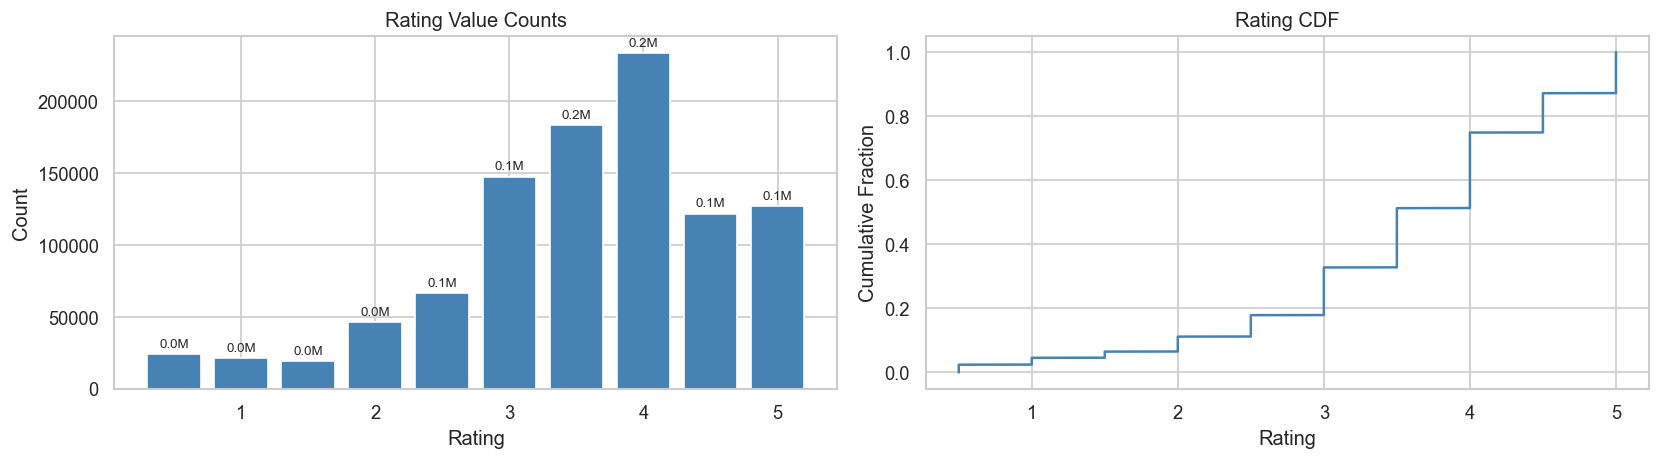

Mean rating: 3.556 | Median: 3.5


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Count plot
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', width=0.4)
axes[0].set_title('Rating Value Counts')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x, y + 5000, f'{y/1e6:.1f}M', ha='center', fontsize=8)

# CDF
sorted_ratings = np.sort(df['rating'].values)
cdf = np.arange(1, len(sorted_ratings)+1) / len(sorted_ratings)
axes[1].plot(sorted_ratings, cdf, color='steelblue')
axes[1].set_title('Rating CDF')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Cumulative Fraction')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'rating_distribution.png')
plt.show()
print(f'Mean rating: {df.rating.mean():.3f} | Median: {df.rating.median()}')

## 3 · User Activity Distribution

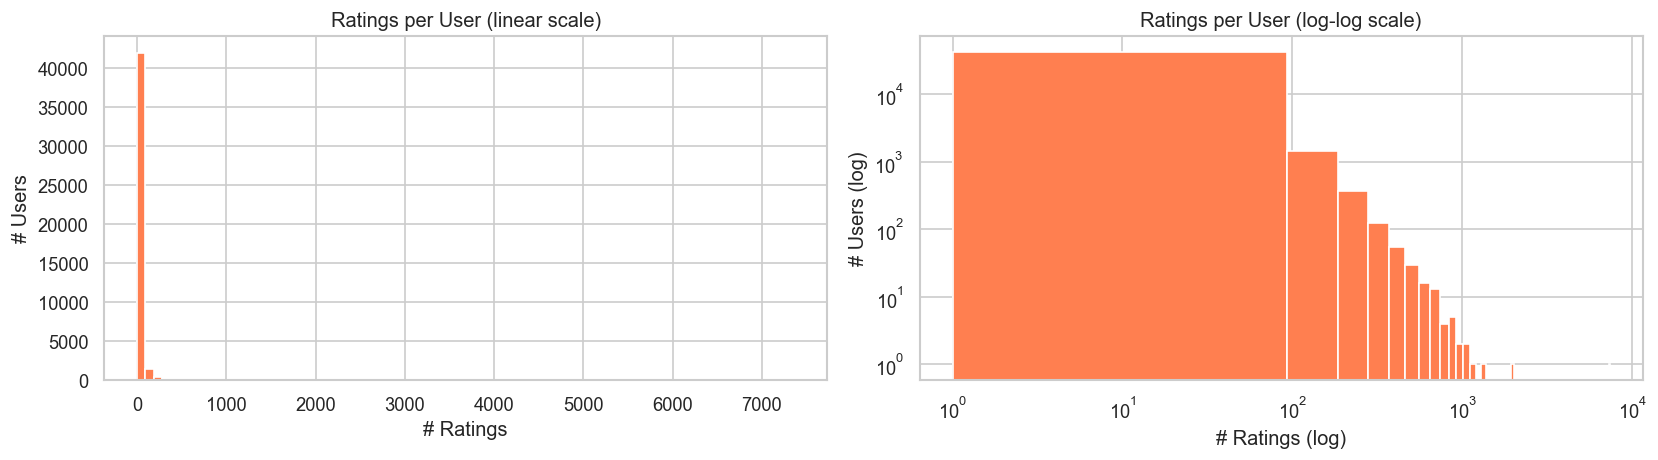

Median ratings/user : 8
Top-1% threshold    : 220
Users < 5 ratings   : 14,614 (33.1%)


In [6]:
user_counts = df.groupby('user_id').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_counts, bins=80, color='coral', edgecolor='white')
axes[0].set_title('Ratings per User (linear scale)')
axes[0].set_xlabel('# Ratings')
axes[0].set_ylabel('# Users')

axes[1].hist(user_counts, bins=80, color='coral', edgecolor='white', log=True)
axes[1].set_xscale('log')
axes[1].set_title('Ratings per User (log-log scale)')
axes[1].set_xlabel('# Ratings (log)')
axes[1].set_ylabel('# Users (log)')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'user_activity.png')
plt.show()

print(f'Median ratings/user : {user_counts.median():.0f}')
print(f'Top-1% threshold    : {user_counts.quantile(0.99):.0f}')
print(f'Users < 5 ratings   : {(user_counts < 5).sum():,} ({(user_counts < 5).mean()*100:.1f}%)')

## 4 · Movie Popularity Distribution

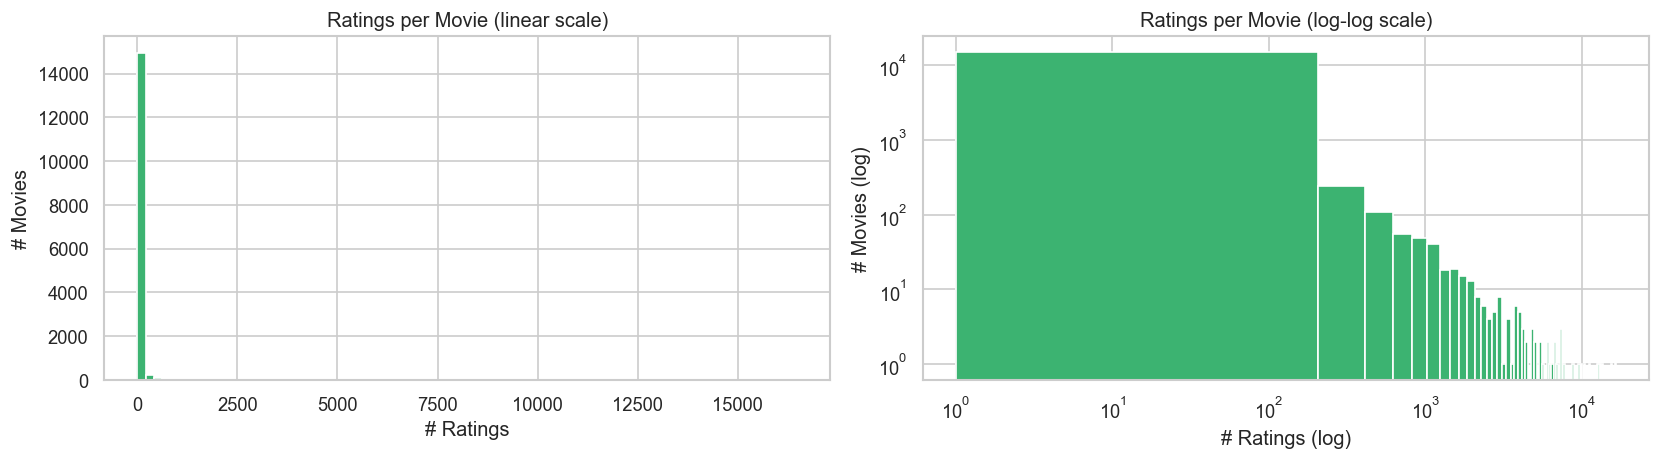

Top-10 most-rated movies:
 movie_id  n_ratings                                             title
     2230      16489                                The Martian (2015)
      759      16324                    Guardians of the Galaxy (2014)
     1027      15520                         The Imitation Game (2014)
     2307      13580                                 Inside Out (2015)
      545      13077                  Grand Budapest Hotel, The (2014)
      739      12818                                  Gone Girl (2014)
     1389      12678 Star Wars: Episode VII - The Force Awakens (2015)
      738      11179                                   Whiplash (2014)
      936      10379                                 Big Hero 6 (2014)
     5946      10087                                    Arrival (2016)


In [7]:
movie_counts = df.groupby('movie_id').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(movie_counts, bins=80, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Ratings per Movie (linear scale)')
axes[0].set_xlabel('# Ratings')
axes[0].set_ylabel('# Movies')

axes[1].hist(movie_counts, bins=80, color='mediumseagreen', edgecolor='white', log=True)
axes[1].set_xscale('log')
axes[1].set_title('Ratings per Movie (log-log scale)')
axes[1].set_xlabel('# Ratings (log)')
axes[1].set_ylabel('# Movies (log)')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'movie_popularity.png')
plt.show()

print('Top-10 most-rated movies:')
top_movies = movie_counts.head(10).reset_index()
top_movies.columns = ['movie_id', 'n_ratings']
if 'title' in df.columns:
    top_movies = top_movies.merge(df[['movie_id','title']].drop_duplicates(), on='movie_id')
print(top_movies.to_string(index=False))

## 5 · Matrix Sparsity

Users          : 44,088
Movies         : 15,603
Ratings        : 990,425
Matrix density : 0.1440%
Matrix sparsity: 99.8560%


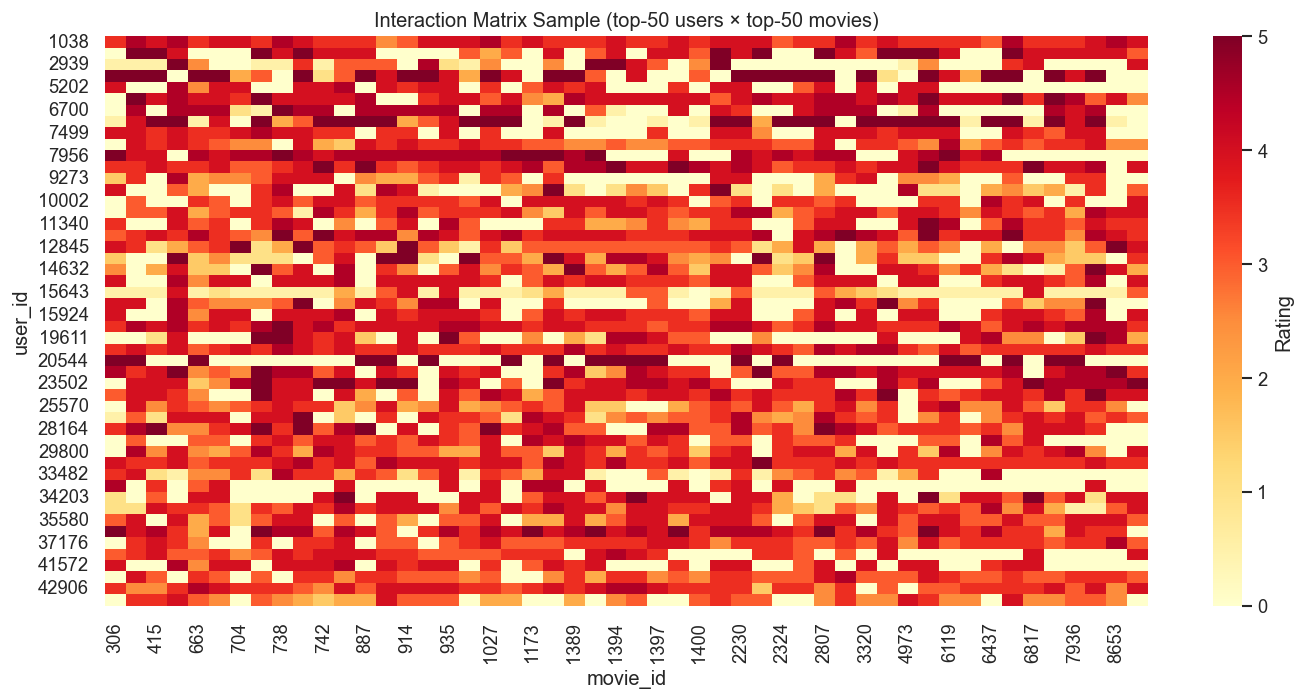

In [8]:
n_users  = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()
n_ratings = len(df)
density  = n_ratings / (n_users * n_movies)
sparsity = 1 - density

print(f'Users          : {n_users:,}')
print(f'Movies         : {n_movies:,}')
print(f'Ratings        : {n_ratings:,}')
print(f'Matrix density : {density*100:.4f}%')
print(f'Matrix sparsity: {sparsity*100:.4f}%')

# Visual heatmap (sample)
sample_users  = df['user_id'].value_counts().head(50).index
sample_movies = df['movie_id'].value_counts().head(50).index
sample_df = df[df['user_id'].isin(sample_users) & df['movie_id'].isin(sample_movies)]
pivot = sample_df.pivot_table(index='user_id', columns='movie_id', values='rating', fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0, cbar_kws={'label': 'Rating'})
plt.title('Interaction Matrix Sample (top-50 users × top-50 movies)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'interaction_heatmap.png')
plt.show()

## 6 · Genre Analysis

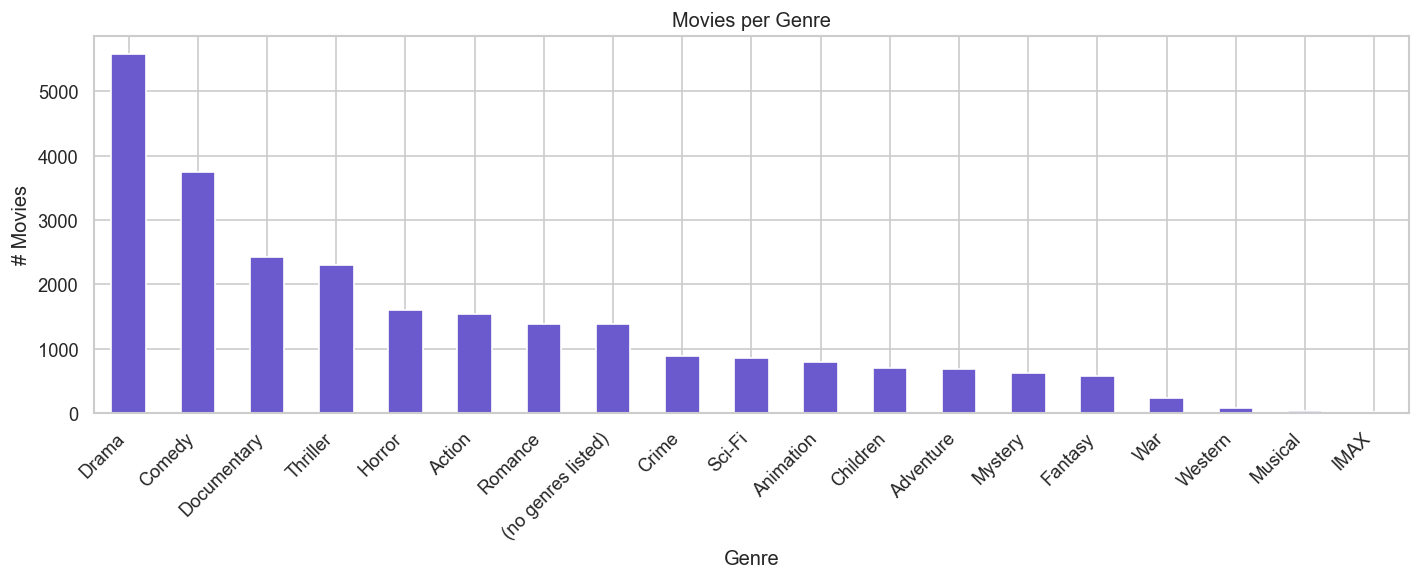

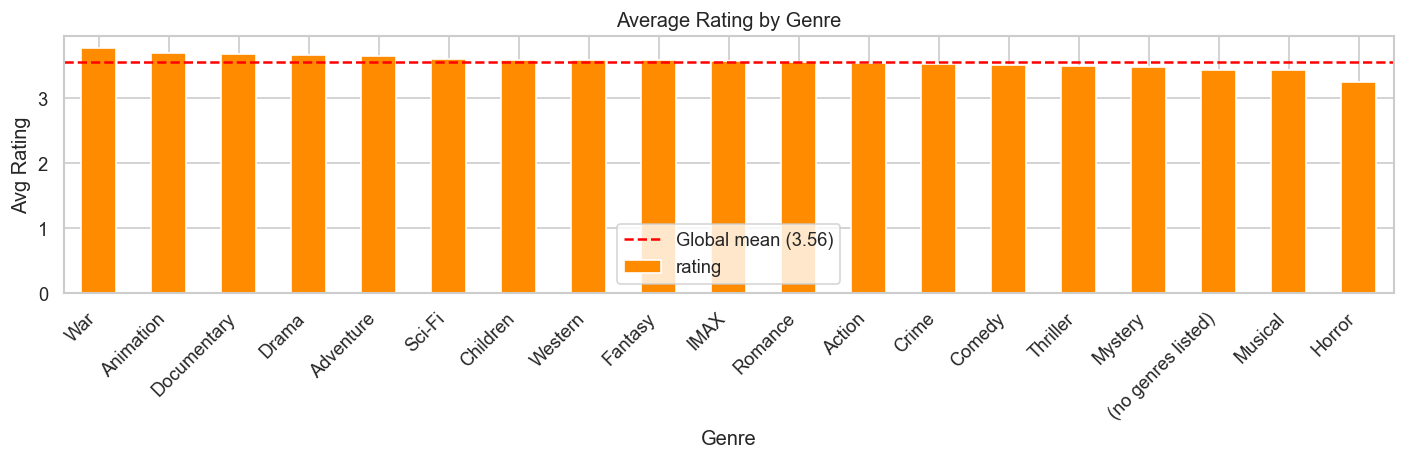

In [9]:
if 'genres' in df.columns:
    genre_df = df[['movie_id', 'genres']].drop_duplicates('movie_id').copy()
    genre_df = genre_df.assign(genre_list=genre_df['genres'].str.split('|'))
    genre_exploded = genre_df.explode('genre_list')
    genre_counts = genre_exploded['genre_list'].value_counts()

    plt.figure(figsize=(12, 5))
    genre_counts.plot(kind='bar', color='slateblue', edgecolor='white')
    plt.title('Movies per Genre')
    plt.xlabel('Genre')
    plt.ylabel('# Movies')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'genre_distribution.png')
    plt.show()

    # Average rating per genre
    ratings_genre = df[['movie_id', 'rating']].merge(genre_df[['movie_id','genre_list']], on='movie_id')
    ratings_genre = ratings_genre.explode('genre_list')
    avg_rating_genre = ratings_genre.groupby('genre_list')['rating'].mean().sort_values(ascending=False)

    plt.figure(figsize=(12, 4))
    avg_rating_genre.plot(kind='bar', color='darkorange', edgecolor='white')
    plt.title('Average Rating by Genre')
    plt.xlabel('Genre')
    plt.ylabel('Avg Rating')
    plt.axhline(df['rating'].mean(), color='red', linestyle='--', label=f'Global mean ({df.rating.mean():.2f})')
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'genre_avg_rating.png')
    plt.show()
else:
    print('No genre column found in raw data.')

## 7 · Key Takeaways

In [10]:
print('=== EDA Summary ===')
print(f'Dataset size    : {n_ratings:,} ratings')
print(f'Users           : {n_users:,}')
print(f'Movies          : {n_movies:,}')
print(f'Sparsity        : {sparsity:.4%}')
print(f'Avg rating      : {df.rating.mean():.3f}')
print(f'Rating std      : {df.rating.std():.3f}')
print(f'Cold-start users: {(user_counts < 5).sum():,}')
print(f'Cold-start items: {(movie_counts < 5).sum():,}')
print()
print('Key insights:')
print(' • Ratings follow a power-law (long tail of inactive users and niche movies)')
print(' • Extreme sparsity — standard for collaborative filtering')
print(' • Ratings skew high (median 4.0) — users tend to rate movies they enjoyed')
print(' • Genre distribution is uneven: Drama/Comedy dominate')

=== EDA Summary ===
Dataset size    : 990,425 ratings
Users           : 44,088
Movies          : 15,603
Sparsity        : 99.8560%
Avg rating      : 3.556
Rating std      : 1.052
Cold-start users: 14,614
Cold-start items: 7,961

Key insights:
 • Ratings follow a power-law (long tail of inactive users and niche movies)
 • Extreme sparsity — standard for collaborative filtering
 • Ratings skew high (median 4.0) — users tend to rate movies they enjoyed
 • Genre distribution is uneven: Drama/Comedy dominate
